<a href="https://colab.research.google.com/github/tusharviradiya/ai-ml/blob/main/11_Practice/week4/End_to_End_Unsupervised_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# ==============================================================================
# 1. DATA LOADING & EXPLORATORY DATA ANALYSIS
# ==============================================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

# Official UCI Machine Learning Repository raw data URL
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00292/Wholesale%20customers%20data.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# Drop non-spending categorical descriptors ('Channel', 'Region')
X = df.drop(columns=["Channel", "Region"])
X.describe()

Dataset Shape: (440, 8)

--- Missing Values Check ---
Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


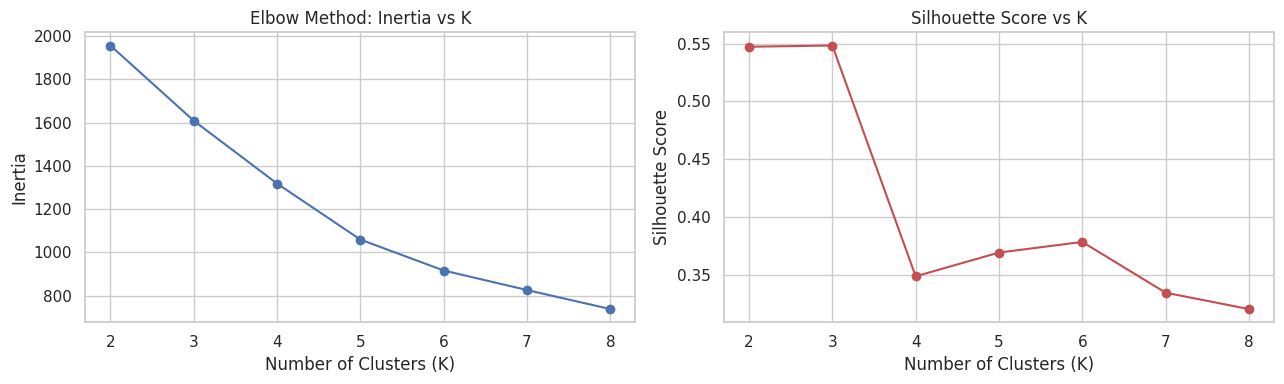

In [6]:
# ==============================================================================
# 2. PREPROCESSING, SCALING & OPTIMAL K SELECTION
# ==============================================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method (Inertia) & Silhouette Analysis
k_range = range(2, 9)
inertias, silhouettes = [], []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X_scaled, kmeans.labels_))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(k_range, inertias, "bo-")
ax[0].set_title("Elbow Method: Inertia vs K", fontsize=12)
ax[0].set_xlabel("Number of Clusters (K)")
ax[0].set_ylabel("Inertia")

ax[1].plot(k_range, silhouettes, "ro-")
ax[1].set_title("Silhouette Score vs K", fontsize=12)
ax[1].set_xlabel("Number of Clusters (K)")
ax[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

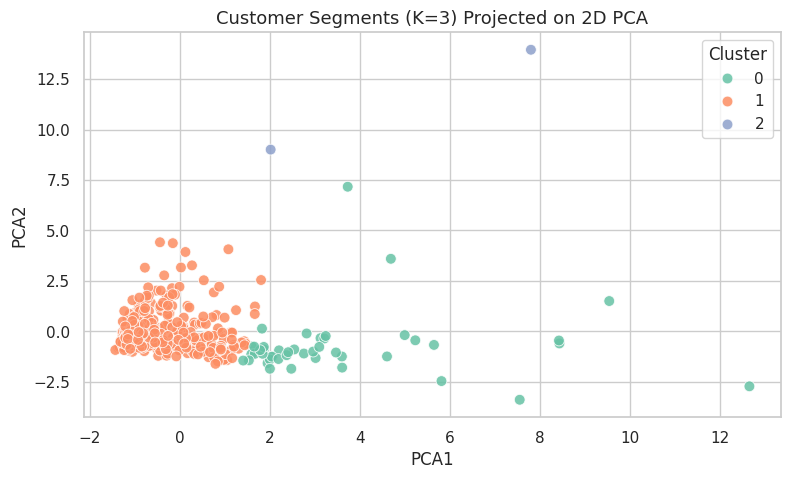

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
Cluster,,,,,,
0,10440.93,19386.42,28656.09,2190.24,13327.80,2374.20
1,12062.91,4115.10,5534.97,2940.68,1696.17,1299.11
2,34782.00,30367.00,16898.00,48701.50,755.50,26776.00


In [7]:
# ==============================================================================
# 3. K-MEANS FITTING, PCA PROJECTION & CLUSTER PROFILING
# ==============================================================================
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# 2D PCA Projection for Visualization
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
df["PCA1"] = pca_coords[:, 0]
df["PCA2"] = pca_coords[:, 1]

plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=60,
    alpha=0.85,
)
plt.title(f"Customer Segments (K={optimal_k}) Projected on 2D PCA", fontsize=13)
plt.show()

# Mean spending profile per cluster
cluster_profile = df.groupby("Cluster")[X.columns].mean().round(2)
display(cluster_profile)

# 4. Result Interpretation & Business Recommendations

### Cluster Interpretations
- **Cluster 0 (Bulk Fresh/Frozen Buyers - Restaurants & Small Markets)**: High average spend on `Fresh` and `Frozen` goods, lower spend on grocery items.
- **Cluster 1 (Retailers / Supermarkets)**: Dominant spending in `Grocery`, `Milk`, and `Detergents_Paper`.
- **Cluster 2 (High-Volume Outliers / Mega Distributors)**: Massive purchasing volume across all product categories.

### Actionable Recommendations
1. **Targeted Promotions**: Provide bundled discounts for `Grocery` + `Detergents_Paper` specifically for Cluster 1 accounts.
2. **Logistics Optimization**: Align cold-chain distribution routes primarily to serve Cluster 0 accounts to minimize food spoilage.